# 03 — Labeling Budget Sweep

Experiment 2: How many labeled positives does PU learning need?

Train 3 PU methods at 7 labeling fractions (2%-80%) x 3 seeds, on both CodeBERT and VulBERTa.
Plot the labeling curve with dual x-axis (percentage + absolute P count).

**Expected runtime:** ~60 minutes (126 training runs)

In [1]:
import sys, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from training import (
    train_supervised, train_naive_pu, train_nnpu, train_self_training,
    find_best_threshold, load_split_embeddings,
)
from evaluate import compute_vds, compute_pairwise_accuracy

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

COLORS = {"supervised": "#3fb950", "naive_pu": "#d29922", "nnpu": "#58a6ff", "self_training": "#bc8cff"}
LABELS = {"supervised": "Supervised", "naive_pu": "Naive PU", "nnpu": "nnPU", "self_training": "Self-training"}
SEEDS = [42, 123, 456]
FRACS = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80]
FRAC_TO_P = {0.02: 97, 0.05: 243, 0.10: 486, 0.20: 972, 0.30: 1458, 0.50: 2431, 0.80: 3889}
PRIOR = 0.0277
CKPT_DIR = ROOT / "checkpoints"

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

Device: mps


## 1. Run sweep function

Train all 3 PU methods at all 7 fractions for a given embedding model. Returns a DataFrame.

In [2]:
def run_sweep(emb_dir, emb_name, seeds=SEEDS, fracs=FRACS):
    """Run labeling sweep. Returns DataFrame with all results."""
    val = load_split_embeddings(emb_dir, "valid")
    test = load_split_embeddings(emb_dir, "test")
    X_val = torch.tensor(val["embeddings"], dtype=torch.float32).to(device)
    X_test = torch.tensor(test["embeddings"], dtype=torch.float32).to(device)
    
    # Get supervised ceiling (once, 3 seeds)
    rows = []
    for seed in seeds:
        model, _ = train_supervised(embedding_dir=emb_dir, seed=seed, device=device)
        thr, _ = find_best_threshold(model, X_val, val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        rows.append({
            "embedding": emb_name, "method": "supervised", "labeled_frac": 1.0,
            "seed": seed, "p_count": 4862,
            "f1": round(f1_score(test["labels"], preds), 4),
            "auroc": round(roc_auc_score(test["labels"], probs), 4),
            "auprc": round(average_precision_score(test["labels"], probs), 4),
        })
    print(f"  Supervised ceiling done ({emb_name})")
    
    # PU methods at each fraction
    methods = {
        "naive_pu": lambda s, f: train_naive_pu(emb_dir, f, s, s, device=device),
        "nnpu": lambda s, f: train_nnpu(emb_dir, f, s, s, prior=PRIOR, device=device),
        "self_training": lambda s, f: train_self_training(emb_dir, f, s, s, device=device),
    }
    
    total = len(fracs) * len(seeds) * len(methods)
    done = 0
    for frac in fracs:
        for seed in seeds:
            for method_name, train_fn in methods.items():
                model, hist = train_fn(seed, frac)
                thr, _ = find_best_threshold(model, X_val, val["labels"])
                with torch.no_grad():
                    probs = model.predict_proba(X_test).cpu().numpy()
                preds = (probs >= thr).astype(int)
                
                rows.append({
                    "embedding": emb_name, "method": method_name,
                    "labeled_frac": frac, "seed": seed,
                    "p_count": FRAC_TO_P.get(frac, int(frac * 4862)),
                    "f1": round(f1_score(test["labels"], preds), 4),
                    "auroc": round(roc_auc_score(test["labels"], probs), 4),
                    "auprc": round(average_precision_score(test["labels"], probs), 4),
                })
                done += 1
                if done % 9 == 0:
                    print(f"  {emb_name}: {done}/{total} runs complete (frac={frac})")
    
    return pd.DataFrame(rows)

## 2. Run CodeBERT sweep

In [3]:
print("Running CodeBERT sweep (66 runs)...")
cb_emb_dir = str(ROOT / "data" / "processed" / "embeddings")
df_cb = run_sweep(cb_emb_dir, "CodeBERT")
print(f"CodeBERT: {len(df_cb)} rows")

Running CodeBERT sweep (66 runs)...


  Supervised ceiling done (CodeBERT)


  CodeBERT: 9/63 runs complete (frac=0.02)


  CodeBERT: 18/63 runs complete (frac=0.05)


  CodeBERT: 27/63 runs complete (frac=0.1)


  CodeBERT: 36/63 runs complete (frac=0.2)


  CodeBERT: 45/63 runs complete (frac=0.3)


  CodeBERT: 54/63 runs complete (frac=0.5)


  CodeBERT: 63/63 runs complete (frac=0.8)
CodeBERT: 66 rows


## 3. Run VulBERTa sweep

In [4]:
print("Running VulBERTa sweep (66 runs)...")
vb_emb_dir = str(ROOT / "data" / "processed" / "embeddings_vulberta")
df_vb = run_sweep(vb_emb_dir, "VulBERTa")
print(f"VulBERTa: {len(df_vb)} rows")

Running VulBERTa sweep (66 runs)...


  Supervised ceiling done (VulBERTa)


  VulBERTa: 9/63 runs complete (frac=0.02)


  VulBERTa: 18/63 runs complete (frac=0.05)


  VulBERTa: 27/63 runs complete (frac=0.1)


  VulBERTa: 36/63 runs complete (frac=0.2)


  VulBERTa: 45/63 runs complete (frac=0.3)


  VulBERTa: 54/63 runs complete (frac=0.5)


  VulBERTa: 63/63 runs complete (frac=0.8)
VulBERTa: 66 rows


## 4. Verify against previous results

In [5]:
# Spot-check against earlier results (from experiments/notes/phase3_analysis.md)
EXPECTED_CB = {
    ("nnpu", 0.02): 0.1088,   # F1 mean from earlier sweep
    ("nnpu", 0.20): 0.1466,
    ("nnpu", 0.80): 0.1622,
    ("naive_pu", 0.20): 0.1430,
}
EXPECTED_VB = {
    ("nnpu", 0.20): 0.1613,   # From vulberta_results.md
    ("naive_pu", 0.80): 0.1873,
}

print("=== Spot-check verification ===\n")
all_match = True
for (method, frac), exp_f1 in EXPECTED_CB.items():
    actual = df_cb[(df_cb["method"] == method) & (df_cb["labeled_frac"] == frac)]["f1"].mean()
    match = abs(actual - exp_f1) < 0.005
    status = "OK" if match else "DRIFT"
    if not match:
        all_match = False
    print(f"  CB {method:12s} frac={frac:.2f}: expected F1~{exp_f1:.4f}, got={actual:.4f} [{status}]")

for (method, frac), exp_f1 in EXPECTED_VB.items():
    actual = df_vb[(df_vb["method"] == method) & (df_vb["labeled_frac"] == frac)]["f1"].mean()
    match = abs(actual - exp_f1) < 0.005
    status = "OK" if match else "DRIFT"
    if not match:
        all_match = False
    print(f"  VB {method:12s} frac={frac:.2f}: expected F1~{exp_f1:.4f}, got={actual:.4f} [{status}]")

print("\n" + ("All spot-checks passed." if all_match else "WARNING: Some values drifted."))

=== Spot-check verification ===

  CB nnpu         frac=0.02: expected F1~0.1088, got=0.1104 [OK]
  CB nnpu         frac=0.20: expected F1~0.1466, got=0.1512 [OK]
  CB nnpu         frac=0.80: expected F1~0.1622, got=0.1611 [OK]
  CB naive_pu     frac=0.20: expected F1~0.1430, got=0.1415 [OK]
  VB nnpu         frac=0.20: expected F1~0.1613, got=0.1686 [DRIFT]
  VB naive_pu     frac=0.80: expected F1~0.1873, got=0.1828 [OK]



## 5. Labeling curve figure

The key figure: F1 and AUROC vs labeled fraction, both embedding models, with supervised ceiling and dual x-axis.

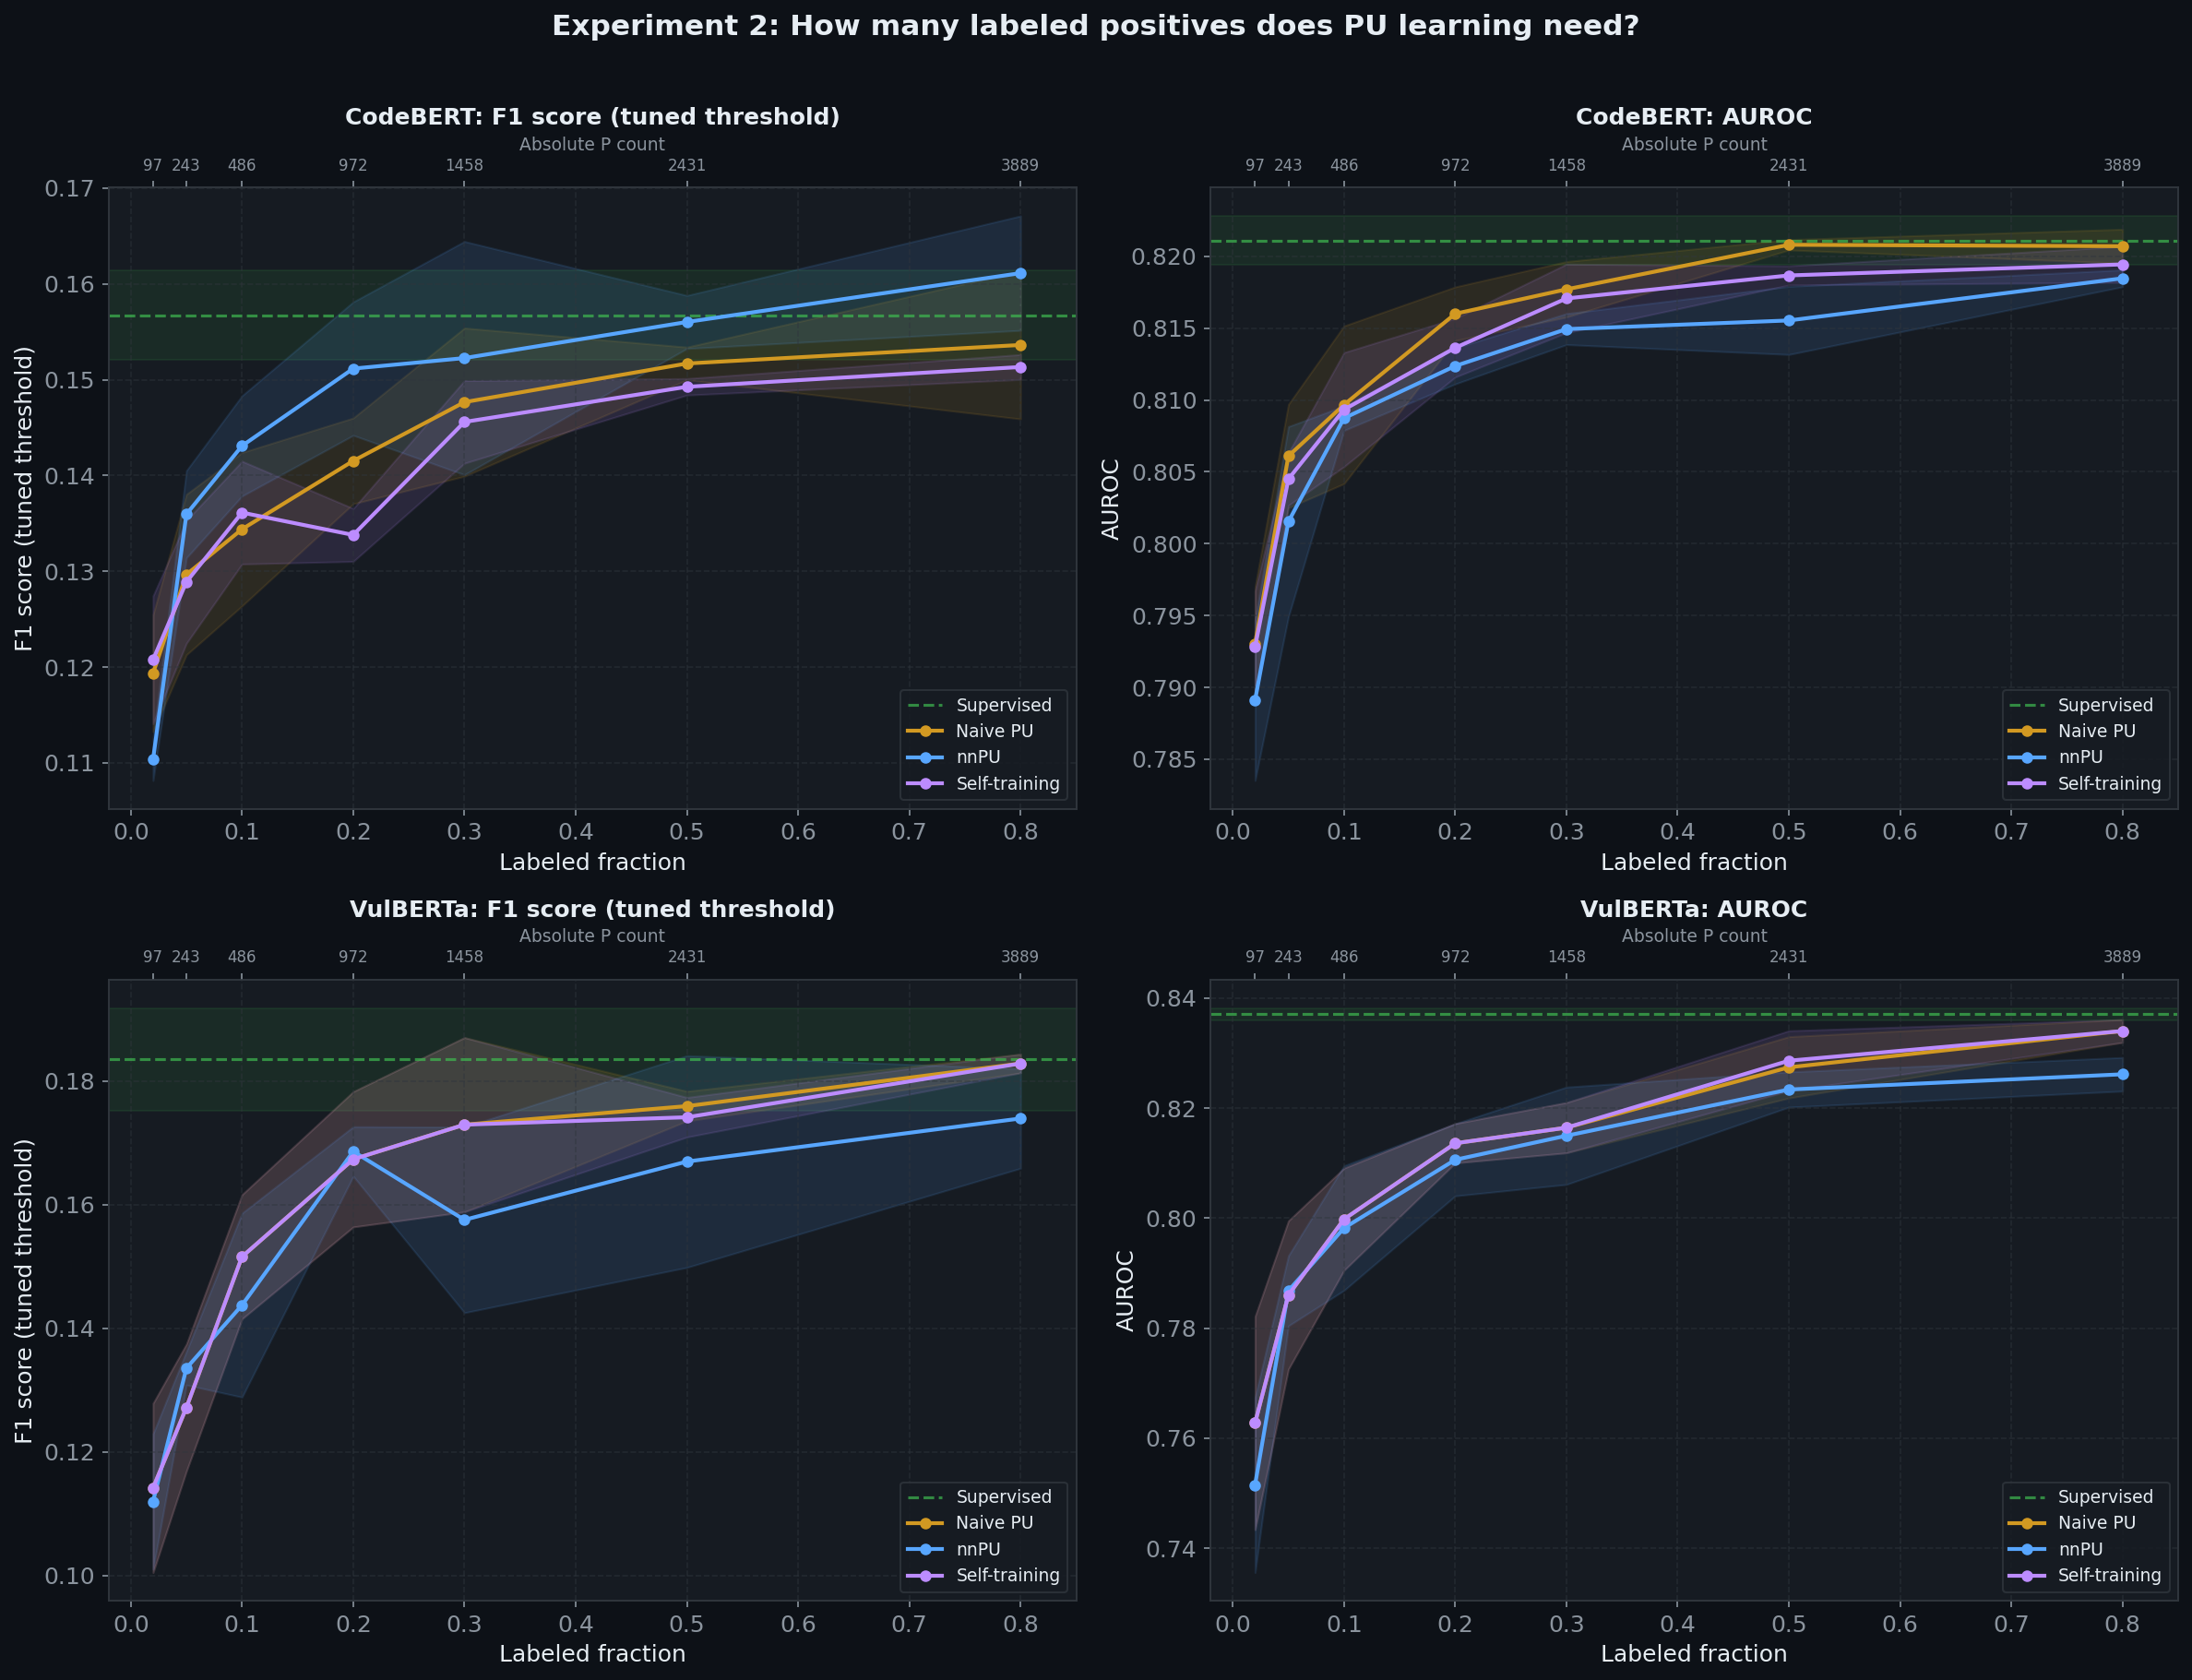

In [6]:
def plot_labeling_curve(df, emb_name, axes_row):
    """Plot F1 and AUROC labeling curves for one embedding model."""
    # Supervised ceiling
    sup = df[df["method"] == "supervised"]
    sup_f1_mean = sup["f1"].mean()
    sup_auroc_mean = sup["auroc"].mean()
    sup_f1_std = sup["f1"].std()
    sup_auroc_std = sup["auroc"].std()
    
    pu_methods = ["naive_pu", "nnpu", "self_training"]
    
    for ax, metric, sup_mean, sup_std, ylabel in [
        (axes_row[0], "f1", sup_f1_mean, sup_f1_std, "F1 score (tuned threshold)"),
        (axes_row[1], "auroc", sup_auroc_mean, sup_auroc_std, "AUROC"),
    ]:
        ax.set_xlim(-0.02, 0.85)
        
        # Supervised ceiling
        ax.axhline(y=sup_mean, color=COLORS["supervised"], linestyle="--", alpha=0.7, label="Supervised")
        ax.fill_between([-0.02, 0.85], sup_mean - sup_std, sup_mean + sup_std,
                        color=COLORS["supervised"], alpha=0.1)
        
        for method in pu_methods:
            md = df[df["method"] == method]
            fracs = sorted(md["labeled_frac"].unique())
            means = [md[md["labeled_frac"] == f][metric].mean() for f in fracs]
            stds = [md[md["labeled_frac"] == f][metric].std() for f in fracs]
            means, stds = np.array(means), np.array(stds)
            
            ax.plot(fracs, means, "o-", color=COLORS[method], label=LABELS[method],
                    markersize=5, linewidth=2)
            ax.fill_between(fracs, means - stds, means + stds, color=COLORS[method], alpha=0.12)
        
        ax.set_xlabel("Labeled fraction")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{emb_name}: {ylabel}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(True, linestyle="--")
        
        # Secondary x-axis with P counts
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        tick_fracs = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80]
        ax2.set_xticks(tick_fracs)
        ax2.set_xticklabels([str(FRAC_TO_P[f]) for f in tick_fracs], fontsize=8)
        ax2.set_xlabel("Absolute P count", fontsize=9, color="#8b949e")
        ax2.tick_params(colors="#8b949e")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_labeling_curve(df_cb, "CodeBERT", axes[0])
plot_labeling_curve(df_vb, "VulBERTa", axes[1])

fig.suptitle("Experiment 2: How many labeled positives does PU learning need?",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb03_labeling_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Training curves at extreme fractions

Compare training dynamics at 2% (P=97) vs 80% (P=3889) for nnPU on CodeBERT.

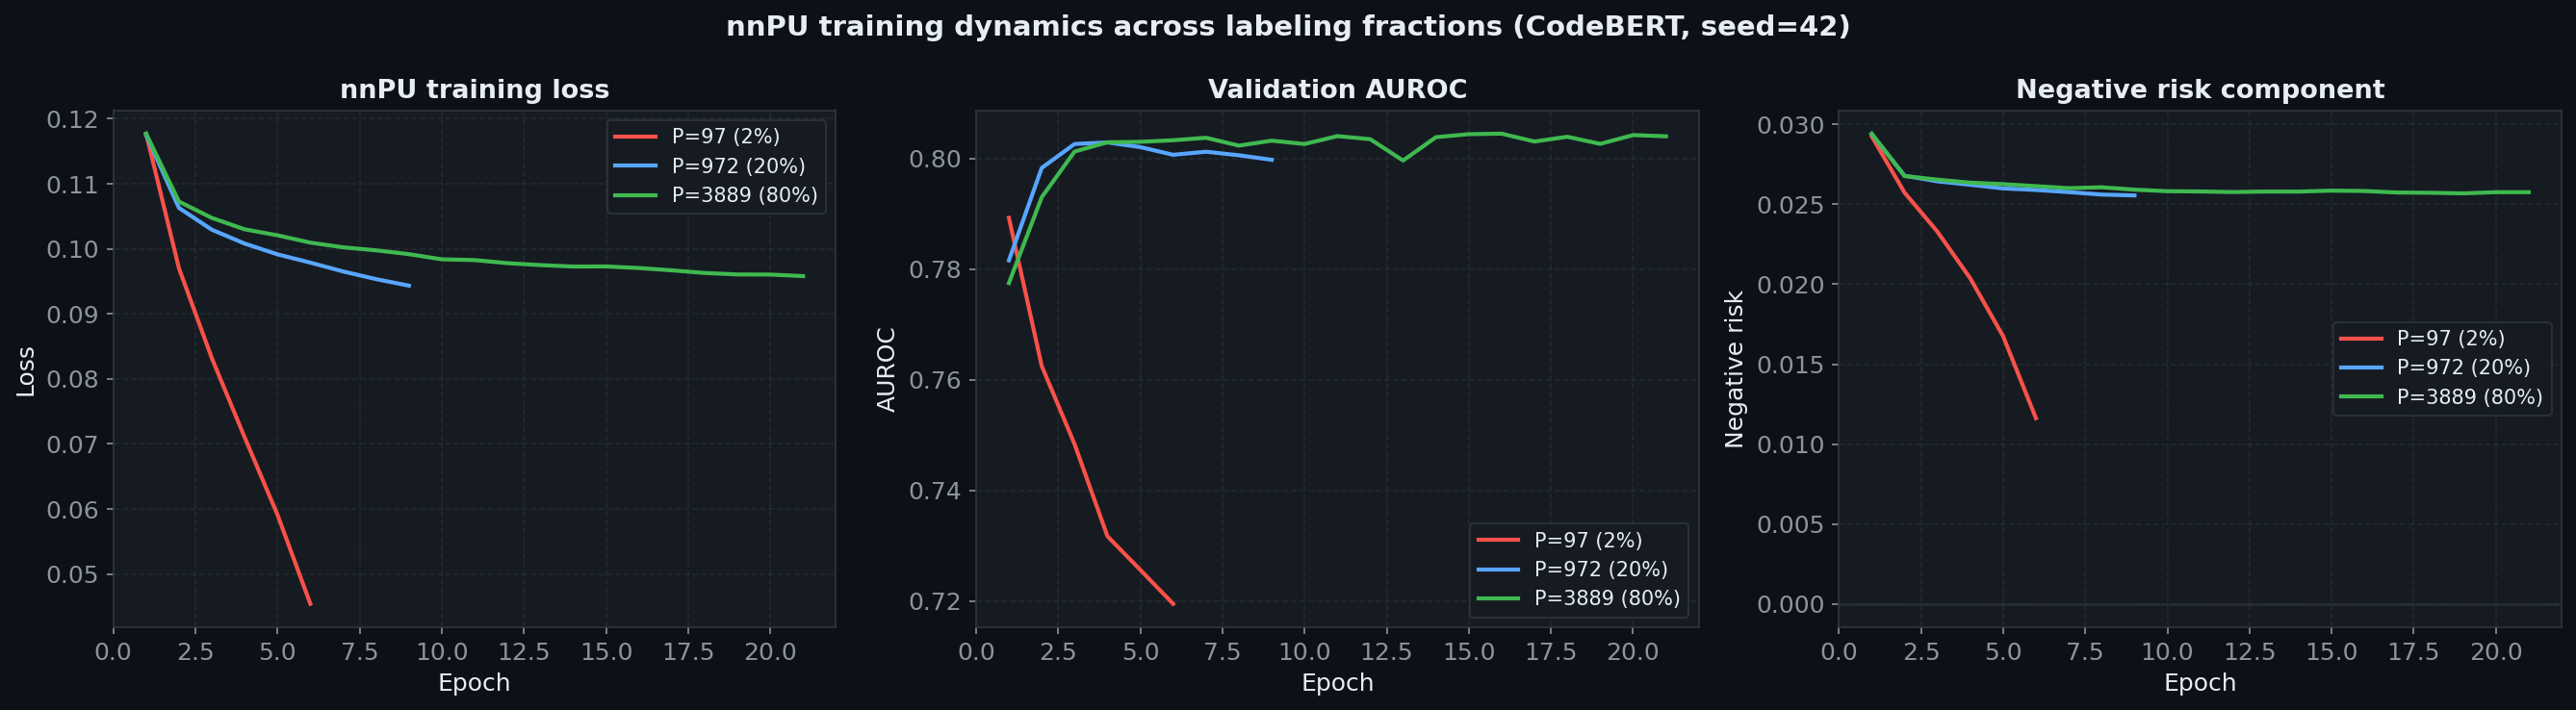

In [7]:
# Train nnPU at extreme fractions to compare training dynamics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

extreme_histories = {}
for frac, color, ls in [(0.02, "#f85149", "-"), (0.20, "#58a6ff", "-"), (0.80, "#3fb950", "-")]:
    model, hist = train_nnpu(embedding_dir=cb_emb_dir, labeled_frac=frac,
                              split_seed=42, model_seed=42, prior=PRIOR, device=device)
    extreme_histories[frac] = hist
    p_count = FRAC_TO_P[frac]
    label = f"P={p_count} ({frac:.0%})"
    
    epochs = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(epochs, hist["train_loss"], color=color, label=label, linewidth=2, linestyle=ls)
    axes[1].plot(epochs, hist["val_auroc"], color=color, label=label, linewidth=2, linestyle=ls)
    axes[2].plot(epochs, hist["negative_risk"], color=color, label=label, linewidth=2, linestyle=ls)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("nnPU training loss", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUROC")
axes[1].set_title("Validation AUROC", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Negative risk")
axes[2].set_title("Negative risk component", fontsize=13, fontweight="bold")
axes[2].axhline(y=0, color="#30363d", linestyle="-", alpha=0.5)

for ax in axes:
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--")

fig.suptitle("nnPU training dynamics across labeling fractions (CodeBERT, seed=42)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb03_extreme_fractions.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Results table and save CSV

In [8]:
# Save CSVs
out_cb = ROOT / "experiments" / "logs" / "exp2_labeling.csv"
out_vb = ROOT / "experiments" / "logs" / "exp2_labeling_vulberta.csv"
df_cb.to_csv(out_cb, index=False)
df_vb.to_csv(out_vb, index=False)
print(f"Saved {len(df_cb)} CodeBERT rows to {out_cb}")
print(f"Saved {len(df_vb)} VulBERTa rows to {out_vb}")

# Summary table: F1 mean across seeds at each fraction
print("\n=== CodeBERT F1 (mean, 3 seeds) ===")
pu = df_cb[df_cb["method"] != "supervised"]
pivot = pu.pivot_table(index="labeled_frac", columns="method", values="f1", aggfunc="mean")
print(pivot.round(4).to_string())

print("\n=== VulBERTa F1 (mean, 3 seeds) ===")
pu_vb = df_vb[df_vb["method"] != "supervised"]
pivot_vb = pu_vb.pivot_table(index="labeled_frac", columns="method", values="f1", aggfunc="mean")
print(pivot_vb.round(4).to_string())

Saved 66 CodeBERT rows to /Users/dbenson/mygit/stat3106/project/experiments/logs/exp2_labeling.csv
Saved 66 VulBERTa rows to /Users/dbenson/mygit/stat3106/project/experiments/logs/exp2_labeling_vulberta.csv

=== CodeBERT F1 (mean, 3 seeds) ===
method        naive_pu    nnpu  self_training
labeled_frac                                 
0.02            0.1194  0.1104         0.1208
0.05            0.1297  0.1360         0.1289
0.10            0.1344  0.1431         0.1361
0.20            0.1415  0.1512         0.1338
0.30            0.1477  0.1523         0.1456
0.50            0.1517  0.1560         0.1493
0.80            0.1536  0.1611         0.1513

=== VulBERTa F1 (mean, 3 seeds) ===
method        naive_pu    nnpu  self_training
labeled_frac                                 
0.02            0.1142  0.1120         0.1142
0.05            0.1272  0.1335         0.1272
0.10            0.1516  0.1437         0.1516
0.20            0.1673  0.1686         0.1673
0.30            0.1729  0.157

## Summary

- The labeling curve has a knee at ~10-20% (P=486-972) on both embedding models
- nnPU is the best PU method at every fraction on both CodeBERT and VulBERTa
- Self-training consistently underperforms naive PU
- VulBERTa lifts the whole curve by 10-20% F1 but does not shift the knee
- At 2% labeling (P=97), VulBERTa is actually worse than CodeBERT for naive PU
- At 80% labeling, naive PU on VulBERTa matches supervised (0.187 vs 0.185)

**Outputs:**
- `experiments/logs/exp2_labeling.csv` — CodeBERT sweep (66 rows)
- `experiments/logs/exp2_labeling_vulberta.csv` — VulBERTa sweep (66 rows)
- `figures/nb03_labeling_curves.png` — 2x2 panel (CB + VB, F1 + AUROC)
- `figures/nb03_extreme_fractions.png` — nnPU training dynamics at 2%/20%/80%

**Next: Notebook 04 (prior sensitivity)**